In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
import random
random.seed(21)


In [68]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"

In [69]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [70]:
model = MultinomialNB()

In [71]:
import pandas as pd

bins = [0, 79, 119, 149, 1000]
labels = ['Low_Price', 'Mid_Price', 'High_Mid_Price', 'High_Price']

price_cols = turnip.columns[1:-1]  # all price columns

for col in price_cols:
    turnip[col] = pd.cut(turnip[col], bins=bins, labels=labels)

In [72]:
turnip

,week,Sunday_AM,Monday_AM,Monday_PM,Tuesday_AM,Tuesday_PM,Wednesday_AM,Wednesday_PM,Thursday_AM,Thursday_PM,Friday_AM,Friday_PM,Saturday_AM,Saturday_PM,Label
0,2021-15,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Mid_Price,Mid_Price,High_Price,High_Price,High_Price,Mid_Price,Mid_Price,Small Spike
1,2021-16,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Mid_Price,High_Mid_Price,High_Price,High_Price,High_Price,Small Spike
2,2021-17,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Decreasing
4,2021-19,Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,High_Price,High_Price,High_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Small Spike
6,2021-21,Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,High_Mid_Price,High_Price,High_Price,Mid_Price,Low_Price,Low_Price,Mid_Price,Low_Price,Low_Price,Large Spike
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2023-16,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Decreasing
106,2023-17,Mid_Price,High_Mid_Price,Mid_Price,High_Price,Mid_Price,High_Mid_Price,High_Mid_Price,Low_Price,Low_Price,Low_Price,High_Mid_Price,Low_Price,Low_Price,Fluctuating
107,2023-18,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Mid_Price,High_Mid_Price,Mid_Price,High_Mid_Price,Fluctuating
108,2023-19,Mid_Price,Mid_Price,High_Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,Low_Price,Low_Price,Mid_Price,High_Mid_Price,Low_Price,Low_Price,Low_Price,Fluctuating


In [73]:
def count_bins(row):
    counts = row.value_counts()
    return pd.Series({
        'low_count': counts.get('Low_Price', 0),
        'mid_count': counts.get('Mid_Price', 0),
        'highmid_count': counts.get('High_Mid_Price', 0),
        'high_count': counts.get('High_Price', 0)
    })

X_counts = turnip[price_cols].apply(count_bins, axis=1)

In [74]:
X_counts

,low_count,mid_count,highmid_count,high_count
0,2,8,0,3
1,4,5,1,3
2,8,5,0,0
4,6,3,1,3
6,4,5,2,2
...,...,...,...,...
105,7,6,0,0
106,5,3,4,1
107,4,7,2,0
108,5,5,3,0


In [75]:
X = X_counts
y = turnip['Label']

In [76]:
xtraining_t, xtesting_t, ytraining_t, ytesting_t = train_test_split(X, y, test_size=0.20)

In [77]:
print("X Training:\n", xtraining_t)

X Training:
      low_count  mid_count  highmid_count  high_count
30           5          5              3           0
27           5          8              0           0
100          4          5              3           1
25           5          5              0           3
35           5          2              6           0
..         ...        ...            ...         ...
42           5          4              4           0
57           7          2              1           3
90           5          5              1           2
32           7          6              0           0
16           5          7              1           0

[83 rows x 4 columns]


In [78]:
print("X Testing:\n", xtesting_t)

X Testing:
      low_count  mid_count  highmid_count  high_count
54           4          5              4           0
84           7          2              2           2
45           4          2              5           2
15           5          6              2           0
38           4          5              1           3
10           5          5              0           3
24           7          2              1           3
40           9          4              0           0
51           4          5              4           0
50           6          4              0           3
108          5          5              3           0
99           9          4              0           0
68           5          3              2           3
28           6          2              2           3
96           4          5              4           0
97           5          3              5           0
59           4          4              5           0
52          12          1         

In [79]:
print("Y Training:\n", ytraining_t)

Y Training:
 30     Fluctuating
27     Fluctuating
100    Large Spike
25     Large Spike
35     Fluctuating
          ...     
42     Fluctuating
57     Small Spike
90     Small Spike
32      Decreasing
16     Fluctuating
Name: Label, Length: 83, dtype: object


In [80]:
print("Y Testing:\n", ytesting_t)

Y Testing:
 54     Fluctuating
84     Small Spike
45     Fluctuating
15     Fluctuating
38     Large Spike
10     Large Spike
24     Small Spike
40      Decreasing
51     Fluctuating
50     Large Spike
108    Fluctuating
99      Decreasing
68     Small Spike
28     Small Spike
96     Fluctuating
97     Fluctuating
59     Fluctuating
52      Decreasing
26     Fluctuating
67      Decreasing
77     Small Spike
Name: Label, dtype: object


In [81]:
model = MultinomialNB()
model.fit(xtraining_t, ytraining_t)
y_pred = model.predict(xtesting_t)

In [82]:
y_pred

array(['Fluctuating', 'Small Spike', 'Small Spike', 'Fluctuating',
       'Large Spike', 'Large Spike', 'Small Spike', 'Decreasing',
       'Fluctuating', 'Large Spike', 'Fluctuating', 'Decreasing',
       'Large Spike', 'Small Spike', 'Fluctuating', 'Fluctuating',
       'Fluctuating', 'Decreasing', 'Fluctuating', 'Decreasing',
       'Small Spike'], dtype='<U11')

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report



accuracy = accuracy_score(ytesting_t, y_pred)
print("Accuracy:", accuracy)
print(classification_report(ytesting_t, y_pred))

Accuracy: 0.9047619047619048
              precision    recall  f1-score   support

  Decreasing       1.00      1.00      1.00         4
 Fluctuating       1.00      0.89      0.94         9
 Large Spike       0.75      1.00      0.86         3
 Small Spike       0.80      0.80      0.80         5

    accuracy                           0.90        21
   macro avg       0.89      0.92      0.90        21
weighted avg       0.92      0.90      0.91        21



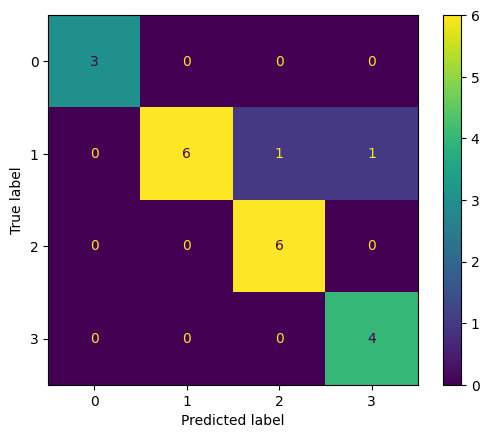

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ytesting_t, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [96]:
from sklearn.metrics import classification_report

print(classification_report(ytesting_t, y_pred))

              precision    recall  f1-score   support

  Decreasing       1.00      1.00      1.00         3
 Fluctuating       1.00      0.75      0.86         8
 Large Spike       0.86      1.00      0.92         6
 Small Spike       0.80      1.00      0.89         4

    accuracy                           0.90        21
   macro avg       0.91      0.94      0.92        21
weighted avg       0.92      0.90      0.90        21

